<a href="https://colab.research.google.com/github/TorresZ314/EE344ML_homework/blob/main/344Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Reproducibility
SEED = 42


In [ ]:
# Load the dataset
DATA_PATH = "merged_dataset.csv"
df = pd.read_csv(DATA_PATH)
df = df.drop(columns = ['filename'])
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

print("\nSummary statistics:")
display(df.describe(include="all"))

print("\nMissing values per column:")
display(df.isna().sum())


Shape: (603, 64)

Columns:
['x_0', 'y_0', 'z_0', 'x_1', 'y_1', 'z_1', 'x_2', 'y_2', 'z_2', 'x_3', 'y_3', 'z_3', 'x_4', 'y_4', 'z_4', 'x_5', 'y_5', 'z_5', 'x_6', 'y_6', 'z_6', 'x_7', 'y_7', 'z_7', 'x_8', 'y_8', 'z_8', 'x_9', 'y_9', 'z_9', 'x_10', 'y_10', 'z_10', 'x_11', 'y_11', 'z_11', 'x_12', 'y_12', 'z_12', 'x_13', 'y_13', 'z_13', 'x_14', 'y_14', 'z_14', 'x_15', 'y_15', 'z_15', 'x_16', 'y_16', 'z_16', 'x_17', 'y_17', 'z_17', 'x_18', 'y_18', 'z_18', 'x_19', 'y_19', 'z_19', 'x_20', 'y_20', 'z_20', 'direction']


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
0,0.646481,0.771554,1.768660e-07,0.683290,0.711169,-0.005896,0.695399,0.647578,-0.021418,0.704892,...,0.645916,0.637718,-0.093269,0.666913,0.669813,-0.083744,0.661707,0.690624,-0.071454,Pointing_Left
1,0.162824,0.676318,-2.872858e-07,0.299672,0.617752,-0.023162,0.377253,0.549926,-0.040260,0.438199,...,0.090932,0.548127,-0.042013,0.114231,0.568613,-0.032944,0.112813,0.586741,-0.029670,Pointing_Right
2,0.863716,0.546938,2.528396e-08,0.810565,0.535083,-0.036838,0.763620,0.547465,-0.063654,0.772106,...,0.904119,0.720734,-0.104208,0.899656,0.659549,-0.097806,0.885778,0.621000,-0.086766,Pointing_Right
3,0.880592,0.755766,-5.697894e-07,0.780115,0.662776,0.026987,0.652597,0.624160,0.015813,0.538131,...,0.510331,0.795934,-0.109579,0.571014,0.808296,-0.105612,0.616264,0.785701,-0.104499,Pointing_Left
4,0.906104,0.576748,-4.809966e-07,0.816000,0.525581,0.001459,0.707359,0.512891,-0.025827,0.608692,...,0.571708,0.608426,-0.114437,0.625317,0.624875,-0.107075,0.668706,0.611069,-0.100873,Pointing_Left



Summary statistics:


,x_0,y_0,z_0,x_1,y_1,z_1,x_2,y_2,z_2,x_3,...,x_18,y_18,z_18,x_19,y_19,z_19,x_20,y_20,z_20,direction
count,603.000000,603.000000,6.030000e+02,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,...,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pointing_Left
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,332
mean,0.715781,0.735929,-3.487243e-07,0.706443,0.683160,0.003729,0.680230,0.634073,-0.004933,0.663679,...,0.600972,0.645125,-0.055950,0.621407,0.658073,-0.046041,0.632897,0.662758,-0.039996,NaN
std,0.225543,0.136449,3.704727e-07,0.144325,0.111320,0.025334,0.103721,0.093750,0.035670,0.115136,...,0.227899,0.137267,0.066078,0.214595,0.136413,0.068018,0.213331,0.131542,0.067879,NaN
min,0.084779,0.349867,-1.604087e-06,0.227501,0.319509,-0.074556,0.324704,0.262256,-0.098541,0.391913,...,-0.019368,0.212147,-0.216320,-0.004502,0.241364,-0.207668,-0.008087,0.261422,-0.207836,NaN
25%,0.637681,0.636364,-5.683308e-07,0.638907,0.619631,-0.014102,0.628731,0.590829,-0.029325,0.597627,...,0.459225,0.577009,-0.107140,0.516716,0.593450,-0.101291,0.551916,0.595459,-0.094182,NaN
50%,0.757556,0.764420,-3.745417e-07,0.724334,0.690265,0.005098,0.690312,0.646569,-0.003555,0.672244,...,0.663837,0.643011,-0.050791,0.684739,0.657576,-0.042030,0.707454,0.677740,-0.036421,NaN
75%,0.870812,0.826535,-5.074367e-08,0.801574,0.759805,0.021948,0.746388,0.690684,0.019525,0.747112,...,0.769731,0.737592,-0.009485,0.770573,0.748555,0.002069,0.772307,0.746388,0.009581,NaN



Missing values per column:


,0
x_0,0
y_0,0
z_0,0
x_1,0
y_1,0
...,...
z_19,0
x_20,0
y_20,0
z_20,0


In [71]:
# Define categorial and numerical columns
CAT_COL = ['direction']
TARGET = 'direction'

# Dynamically select all columns that are not categorical
NUM_COLS = [col for col in df.columns if col not in CAT_COL]
# Reload data to ensure we recover from any previous empty state
if 'DATA_PATH' in locals():
    df = pd.read_csv(DATA_PATH)
    # Drop filename if it exists, matching the initial load step
    if 'filename' in df.columns:
        df = df.drop(columns=['filename'])

# Coerce numerical columns to numbers, turning errors into NaNs
df[NUM_COLS] = df[NUM_COLS].apply(pd.to_numeric, errors="coerce")

# Only drop rows where NUMERICAL columns are NaN
# We avoid dropping based on the target column to prevent losing categorical data
df = df.dropna(subset=NUM_COLS).reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("Missing values:\n", df.isna().sum())
print(df[NUM_COLS].shape)

Rows after cleaning: 603
Missing values:
 x_0          0
y_0          0
z_0          0
x_1          0
y_1          0
            ..
z_19         0
x_20         0
y_20         0
z_20         0
direction    0
Length: 64, dtype: int64
(603, 63)


In [ ]:
# One hot encoding
# 1. Separate Features and Target
X_raw = df[NUM_COLS]
y_raw = df[[TARGET]]

# 2. Encode the target using OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_ohe = ohe.fit_transform(y_raw)
y_ohe = pd.DataFrame(y_ohe, columns=ohe.get_feature_names_out([TARGET]))

print("Target shape after OHE:", y_ohe.shape)
print("Target columns:", y_ohe.columns.tolist())

# 3. Split 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_ohe, test_size=0.30, random_state=SEED, stratify=y_ohe
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape,  y_test.shape)

display(y_train.head())

Target shape after OHE: (603, 2)
Target columns: ['direction_Pointing_Left', 'direction_Pointing_Right']
Train: (422, 63) (422, 2)
Test : (181, 63) (181, 2)


,direction_Pointing_Left,direction_Pointing_Right
459,0.0,1.0
453,1.0,0.0
348,0.0,1.0
84,1.0,0.0
157,0.0,1.0


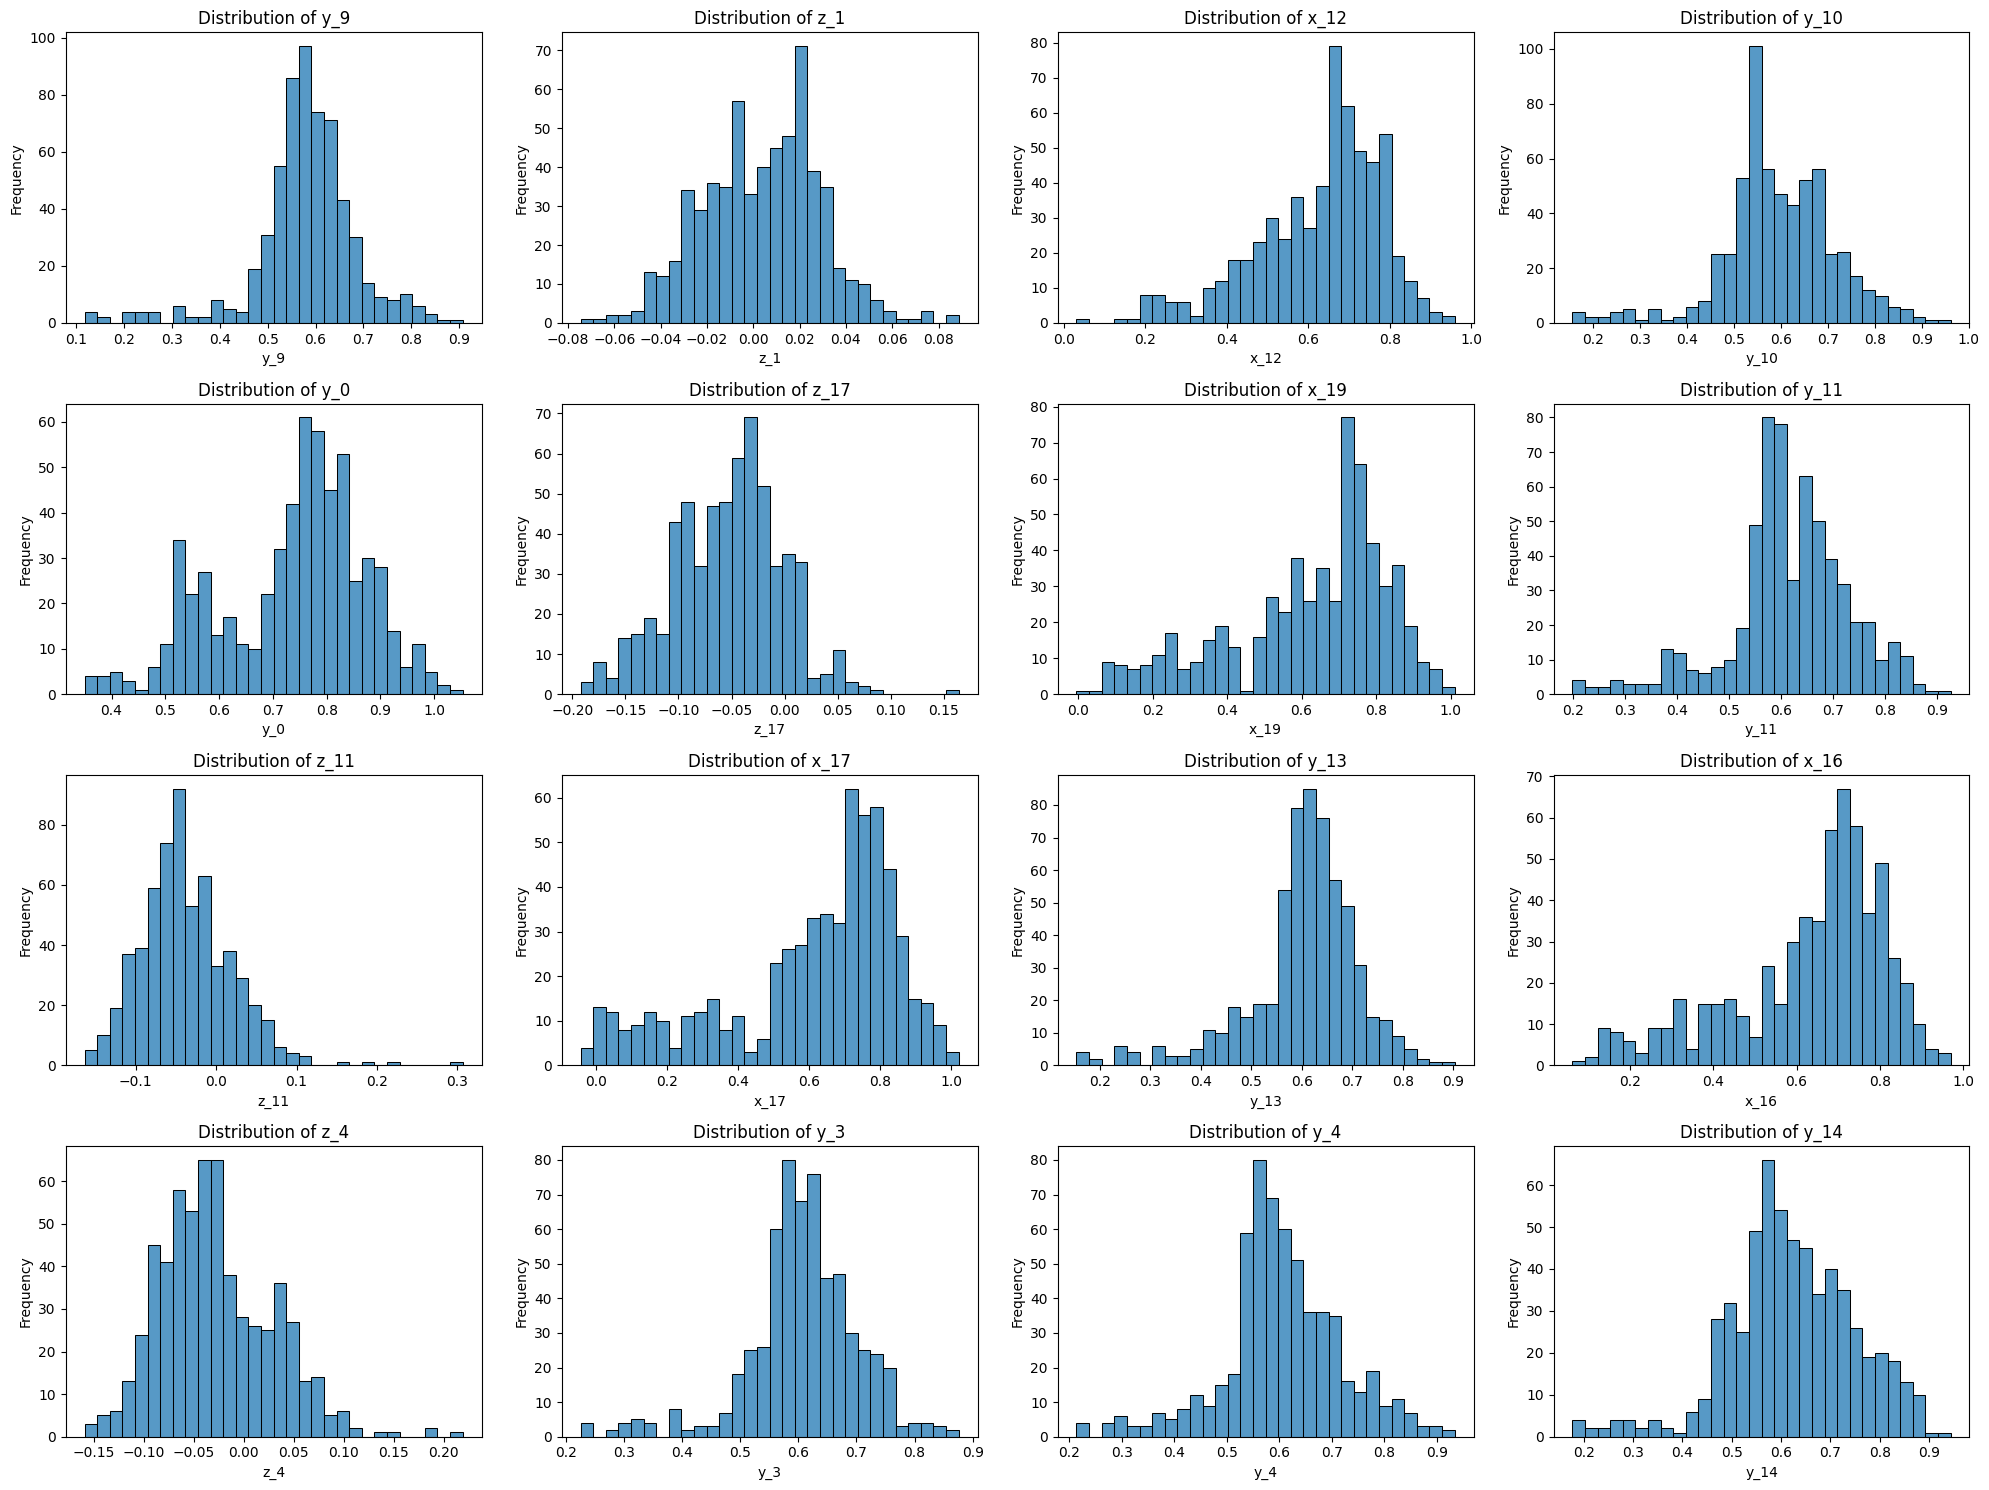

In [ ]:

n_features_to_plot = 16

cols_to_plot = random.sample(NUM_COLS, n_features_to_plot)

plt.figure(figsize=(20, 15))
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 4, i + 1)
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [67]:
# Scale the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
models = {
    "Logistic Regression": LogisticRegression(solver = "saga", max_iter = 2000, n_jobs = -1, random_state = 42),
    "Perceptron": Perceptron(max_iter=1000, tol=1e-3, random_state=42),
    "SVM (LinearSVC)": LinearSVC(random_state=42),
    "KNN (euclidean)": KNeighborsClassifier(n_neighbors=7, metric="euclidean", n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=40, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
}
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=2000, n_jobs=-1, random_state=42, solver='saga')), ('Perceptron', Perceptron(random_state=42)), ('SVM (LinearSVC)', LinearSVC(random_state=42)), ('KNN (euclidean)', KNeighborsClassifier(metric='euclidean', n_jobs=-1, n_neighbors=7)), ('Decision Tree', DecisionTreeClassifier(max_depth=40, random_state=42)), ('Random Forest', RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42))])

In [69]:
# Helper Method
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def metrics(y_true, y_pred):
    """Return (accuracy, precision, recall, f1)."""
    acc = accuracy_score(y_true, y_pred)

    # Use 'binary' for binary classification, otherwise fallback to macro.
    avg = "binary" if len(np.unique(y_true)) == 2 else "macro"

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average=avg, zero_division=0
    )
    return acc, prec, rec, f1

In [70]:
results = []

# Convert OHE targets back to 1D class labels for these models
# (argmax gives the index of the 1, which corresponds to the class)
y_train_labels = np.argmax(y_train.values, axis=1)
y_test_labels = np.argmax(y_test.values, axis=1)

# --- your loop here ---
for model_name, model in models.items():

      # Fit on the 1D labels
      model.fit(X_train_scaled, y_train_labels)

      y_train_pred = model.predict(X_train_scaled)
      y_test_pred = model.predict(X_test_scaled)

      acc_train, prec_train, rec_train, f1_train = metrics(y_train_labels, y_train_pred)
      acc_test, prec_test, rec_test, f1_test = metrics(y_test_labels, y_test_pred)

      results.append([model_name, acc_train, prec_train, rec_train, f1_train,
                      acc_test, prec_test, rec_test, f1_test])


cols = [
    "Model",
    "Train Acc", "Train Prec", "Train Rec", "Train F1",
    "Test Acc", "Test Prec", "Test Rec", "Test F1",
]

out = pd.DataFrame(results, columns=cols).sort_values("Test F1", ascending=False).reset_index(drop=True)

pd.set_option("display.max_colwidth", 80)
print("\n=== Results (sorted by Test F1) ===")
print(out.to_string(index=False, formatters={
    "Train Acc": "{:.4f}".format,
    "Train Prec": "{:.4f}".format,
    "Train Rec": "{:.4f}".format,
    "Train F1": "{:.4f}".format,
    "Test Acc": "{:.4f}".format,
    "Test Prec": "{:.4f}".format,
    "Test Rec": "{:.4f}".format,
    "Test F1": "{:.4f}".format,
}))


=== Results (sorted by Test F1) ===
              Model Train Acc Train Prec Train Rec Train F1 Test Acc Test Prec Test Rec Test F1
      Random Forest    1.0000     1.0000    1.0000   1.0000   0.9945    1.0000   0.9877  0.9938
Logistic Regression    0.9976     1.0000    0.9947   0.9974   0.9890    0.9877   0.9877  0.9877
    SVM (LinearSVC)    1.0000     1.0000    1.0000   1.0000   0.9890    0.9877   0.9877  0.9877
    KNN (euclidean)    0.9953     0.9947    0.9947   0.9947   0.9779    0.9753   0.9753  0.9753
         Perceptron    0.9929     0.9895    0.9947   0.9921   0.9669    0.9412   0.9877  0.9639
      Decision Tree    1.0000     1.0000    1.0000   1.0000   0.9392    0.9070   0.9630  0.9341
